# VEST Daily Monitoring

## Overview

After a run day, three questions decide what happens next: did the shots fire,
did they make plasma, and is anything different enough to be worth a person's
attention. This page answers them for a list of shots and stops there — it is a
morning review, not an analysis.

It runs on the shots packaged with VAFT so it executes anywhere; point `SHOTS`
at a day's numbers and the same cells report on those instead.

## Pipeline context

Downstream of raw-signal loading and diagnostics processing; upstream of
anything that picks shots to study. `shot_characteristics_classification.ipynb`
builds the per-shot record a campaign analysis reads — this page is the daily
read of the same quantities.

## The day's shots, on a common clock

Shots are compared on the loop-voltage convention rather than the DAQ clock:
each shot's origin is its own breakdown, so a duration or an onset delay means
the same thing across the list. `change_time_convention` records which event it
used and where it found it.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from omas import ODC

import vaft
from vaft.omas.plasma_timing import plasma_timing

# A day's shot list. The packaged samples stand in for one here.
SHOTS = (39915, 41524, 41672)

odc = ODC()
for shot in SHOTS:
    odc[str(shot)] = vaft.omas.load(vaft.data.sample(shot, representation="omas"))
vaft.omas.change_time_convention(odc)

for shot in SHOTS:
    parameters = odc[str(shot)]["summary.code.parameters"]
    print(f"[{shot}] t = 0 at {parameters['vloop_onset']:.5f} s on the DAQ clock "
          f"({parameters['vloop_onset_source']})")

<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0


00:54:24 INFO     Parsing data dictionary version 3.41.0 @dd_zip.py:89


em_coupling.code.parameters is not formatted as XML


em_coupling.code.parameters is not formatted as XML


[39915] t = 0 at 0.30224 s on the DAQ clock (magnetics.flux_loop.5 dflux_dt zero crossing after the ohmic excursion)
[41524] t = 0 at 0.31148 s on the DAQ clock (magnetics.flux_loop.5 dflux_dt zero crossing after the ohmic excursion)
[41672] t = 0 at 0.31112 s on the DAQ clock (magnetics.flux_loop.5 dflux_dt zero crossing after the ohmic excursion)


## The day at a glance

One row per shot. The class comes from the gas, the light and the current;
the window from `plasma_timing`, which also reports which detector decided it
and whether the current agrees with the light. A shot where they disagree is
the one to open first.

In [ ]:
def summary_row(shot, ods):
    timing = plasma_timing(ods)
    current = np.asarray(ods["magnetics.ip.0.data"], dtype=float)
    row = {
        "shot": shot,
        "class": vaft.omas.classify_shot(ods),
        "onset_ms": None if not timing.found else timing.onset * 1e3,
        "duration_ms": None if not timing.found else (timing.offset - timing.onset) * 1e3,
        "decided_by": timing.source,
        "agreement": timing.agreement,
        "peak_Ip_kA": float(np.nanmax(np.abs(current))) / 1e3,
        "B0_T": float(vaft.omas.find_bt(ods)),
        "IDS": len(ods.keys()),
    }
    return row


day = pd.DataFrame([summary_row(shot, odc[str(shot)]) for shot in SHOTS]).set_index("shot")
print(day.to_string(float_format=lambda value: f"{value:.4g}"))

        class  onset_ms  duration_ms       decided_by   agreement  peak_Ip_kA   B0_T  IDS
shot                                                                                     
39915  Plasma      4.08        24.48  h_alpha_primary  consistent       84.14 0.1499   10
41524  Plasma      3.08        21.88  h_alpha_primary  consistent       223.1 0.1734   12
41672  Plasma      1.08        39.52  h_alpha_primary  consistent         127 0.1732   12


## Each shot, one figure

The diagnostics overview is the same panel set for every shot, so the eye
compares like with like: plasma current, the light, the fill, the coils.

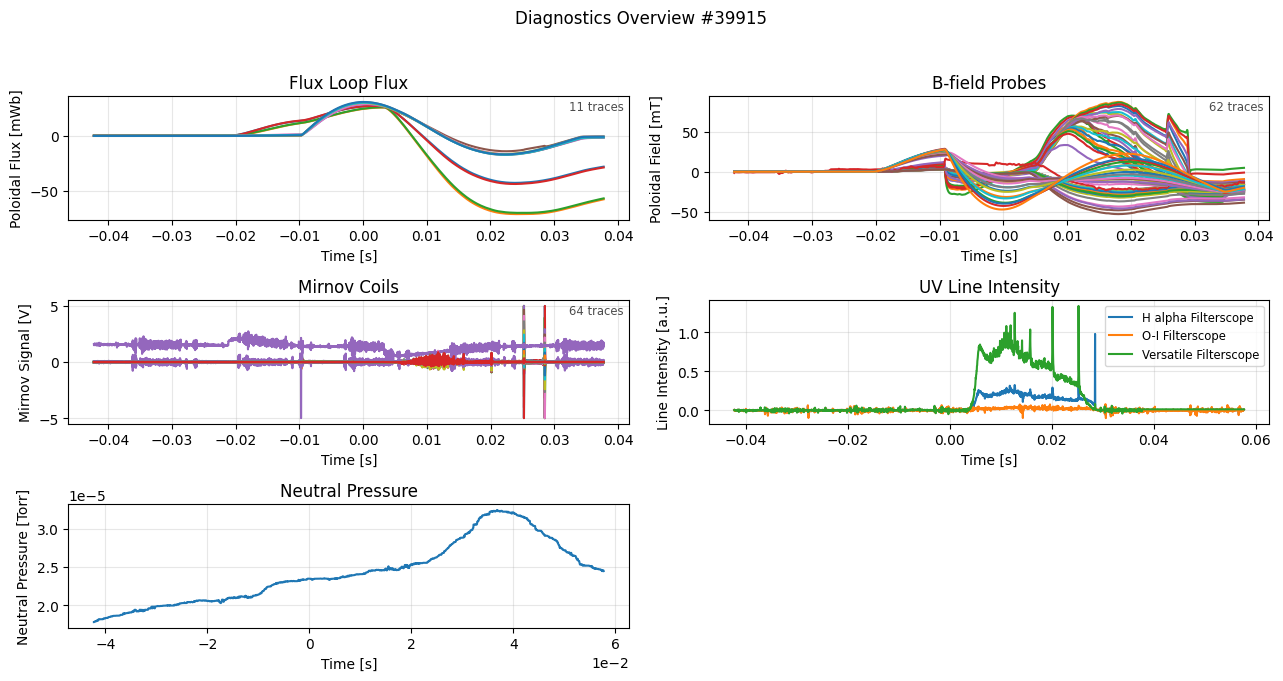

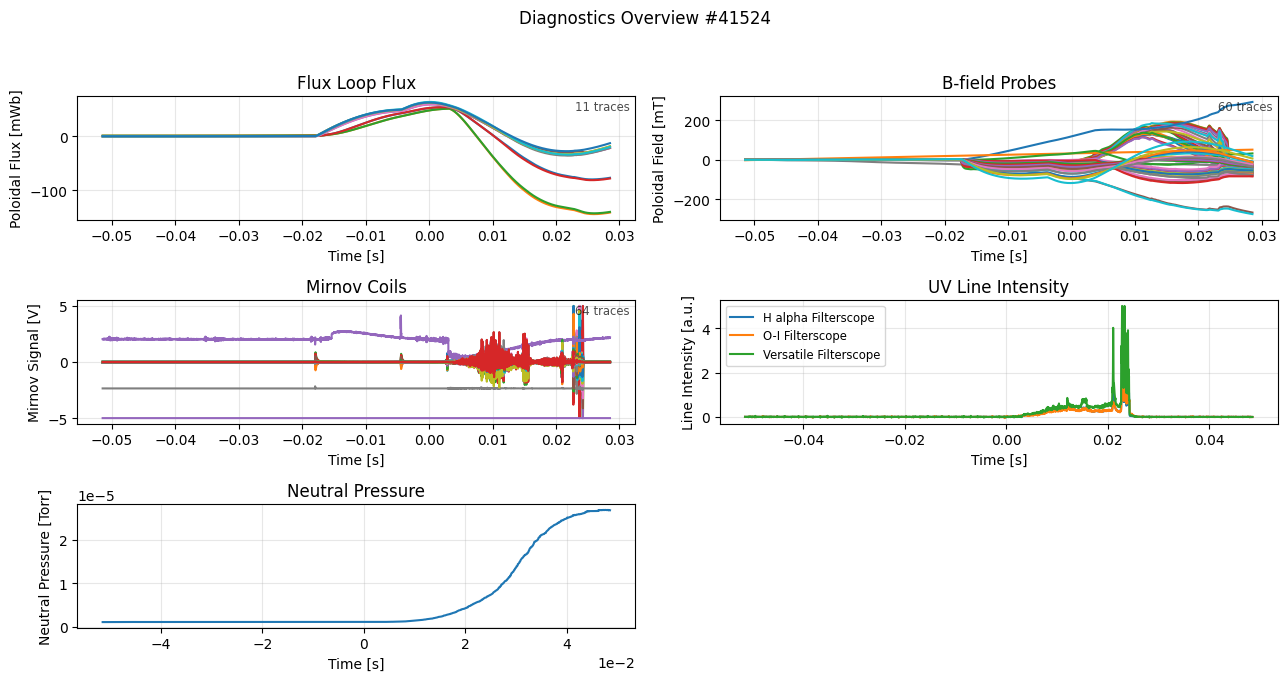

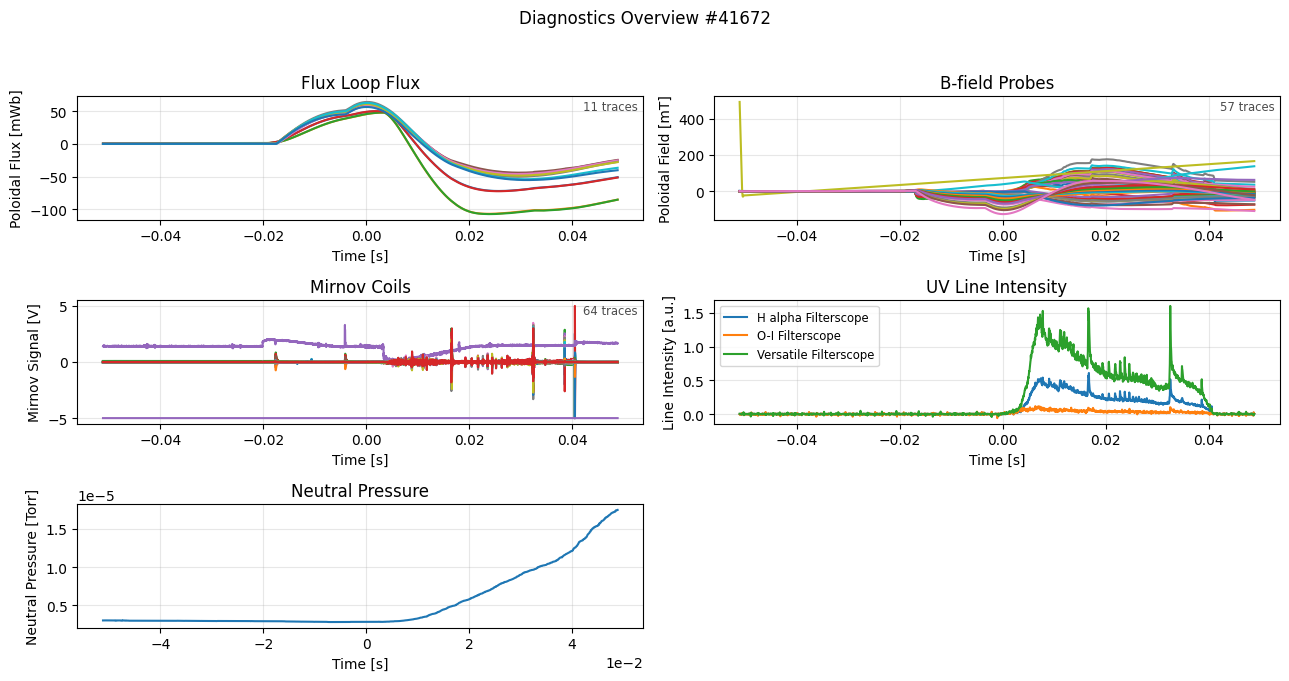

In [ ]:
for shot in SHOTS:
    vaft.omas.plot_diagnostics_overview(odc[str(shot)], label=[str(shot)], show=True)

## The shots against each other

On the common clock, the traces overlay directly. Differences in rise, duration
and light level are the day's story.

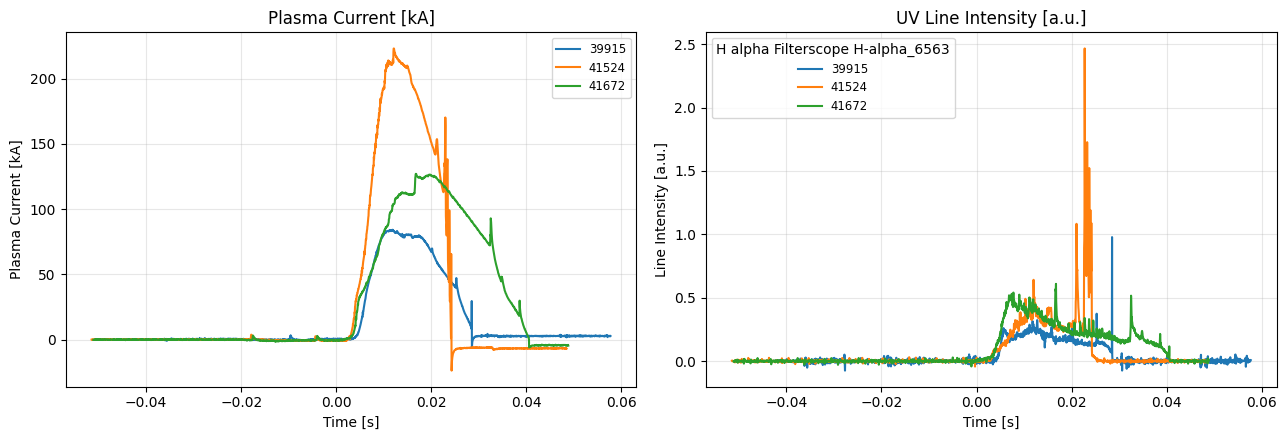

In [ ]:
entries = [odc[str(shot)] for shot in SHOTS]
labels = [str(shot) for shot in SHOTS]

fig, (ax_ip, ax_light) = plt.subplots(1, 2, figsize=(13, 4.5))
vaft.omas.plot_plasma_current_time(entries, label=labels, ax=ax_ip)
vaft.omas.plot_spectrometer_uv_time_intensity(
    entries, label=labels, selection=0, emission=["H"], ax=ax_light
)
fig.tight_layout()
plt.show()

## What needs a person

Three checks a reviewer would otherwise do by eye. None of them decides
anything: they say which shot to open, and why.

In [ ]:
reference = set(odc[str(SHOTS[0])].keys())
median_duration = float(day["duration_ms"].median())

for shot in SHOTS:
    ods = odc[str(shot)]
    notes = []

    timing = plasma_timing(ods)
    if timing.agreement != "consistent":
        notes.append(f"light and current disagree ({timing.agreement})")
    if timing.flags:
        notes.append("timing flags: " + ", ".join(timing.flags))

    missing = reference - set(ods.keys())
    if missing:
        notes.append("no " + ", ".join(sorted(missing)))

    duration = day.loc[shot, "duration_ms"]
    if duration is not None and abs(duration - median_duration) > 0.5 * median_duration:
        notes.append(f"duration {duration:.0f} ms against a median of {median_duration:.0f} ms")

    print(f"{shot}: " + ("; ".join(notes) if notes else "nothing flagged"))

39915: nothing flagged
41524: nothing flagged
41672: duration 40 ms against a median of 24 ms


## Pointing this at a real day

Replace `SHOTS` with the day's numbers and load them from the database instead
of the packaged samples:

```python
odc[str(shot)] = vaft.database.open(shot)
```

Everything after that cell is unchanged: the same convention, the same table,
the same overview per shot, the same three checks.